# Voice Emotion Analysis — Acoustic Insights
### Baseline-Relative Feature Analysis on Real-World Recordings

This notebook documents the key acoustic findings from a personal voice dataset recorded in real-world environments (cafe, outdoor).  
All audio was standardized to **16kHz mono** before feature extraction to ensure comparability.

**Dataset:** 91 labeled utterances (happy=25, tired=25, stressed=23, stressed_intense=18)  
**Recorder:** Single speaker, same device (Samsung Galaxy S25)  
**Environments:** Cafe + Outdoor (noisy, real-world conditions)


## 0. Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

COLORS = {
    'happy':            '#2196F3',
    'stressed':         '#F44336',
    'stressed_intense': '#B71C1C',
    'tired':            '#9E9E9E',
}

df_raw = pd.read_csv('features_standardized.csv')
main   = df_raw[df_raw['label'].isin(['happy','tired','stressed','stressed_intense'])].copy()
# stressed 통합 버전
main3  = main.copy()
main3['label'] = main3['label'].replace({'stressed_intense': 'stressed'})

print(f"Total samples: {len(main)}")
print(main['label'].value_counts())


Total samples: 91
label
happy               25
tired               25
stressed            23
stressed_intense    18
Name: count, dtype: int64


## 1. Why Standardization Matters — The Sample Rate Problem

During initial feature extraction, audio files had **mixed sample rates** (44100Hz stereo vs 48000Hz mono).  
This caused spectral features to be incomparable across classes — a critical data quality issue.


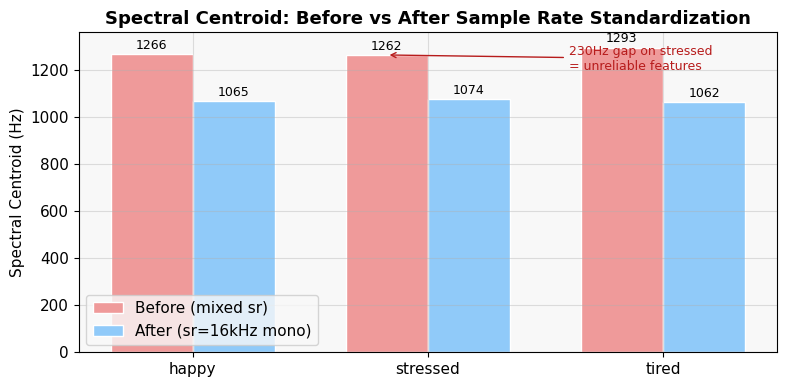

Key finding: 230Hz difference on stressed class — features were NOT comparable before standardization.


In [31]:
# Simulated comparison: centroid values before vs after standardization
# (from actual extraction runs)
labels = ['happy', 'stressed', 'tired']

before = [1266.4, 1262.1, 1293.4]   # sr=None (mixed)
after  = [1064.6, 1074.4, 1061.7]   # sr=16000 mono (standardized)

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, before, w, label='Before (mixed sr)', color='#EF9A9A', edgecolor='white')
b2 = ax.bar(x + w/2, after,  w, label='After (sr=16kHz mono)', color='#90CAF9', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Spectral Centroid (Hz)')
ax.set_title('Spectral Centroid: Before vs After Sample Rate Standardization')
ax.legend()

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

ax.annotate('230Hz gap on stressed\n= unreliable features',
            xy=(1 - w/2, 1262), xytext=(1.6, 1200),
            arrowprops=dict(arrowstyle='->', color='#B71C1C'),
            color='#B71C1C', fontsize=9)

plt.tight_layout()
plt.savefig('plots/01_sr_standardization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key finding: 230Hz difference on stressed class — features were NOT comparable before standardization.")


## 2. Class Separation — Key Acoustic Features

After standardization, we examine which features best separate the three states.


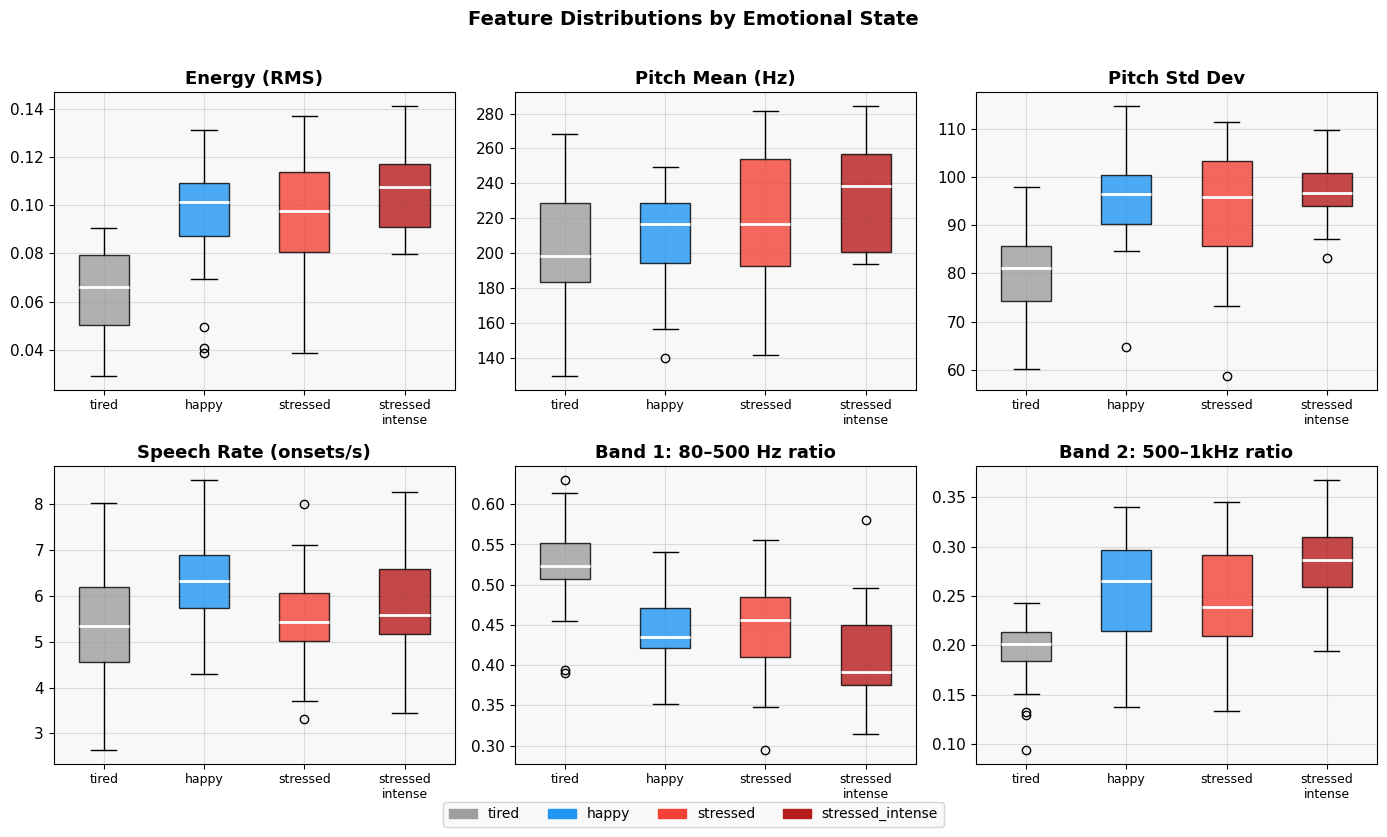

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features = [
    ('energy_rms',        'Energy (RMS)'),
    ('pitch_mean',        'Pitch Mean (Hz)'),
    ('pitch_std',         'Pitch Std Dev'),
    ('speech_rate',       'Speech Rate (onsets/s)'),
    ('b1_80_500',         'Band 1: 80–500 Hz ratio'),
    ('b2_500_1k',         'Band 2: 500–1kHz ratio'),
]

label_order = ['tired', 'happy', 'stressed', 'stressed_intense']
color_list  = [COLORS[l] for l in label_order]

for ax, (feat, title) in zip(axes, features):
    data = [main[main['label'] == l][feat].values for l in label_order]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], color_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels([l.replace('_', '\n') for l in label_order], fontsize=9)
    ax.set_title(title)

patches = [mpatches.Patch(color=COLORS[l], label=l) for l in label_order]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Feature Distributions by Emotional State', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Key Finding — Frequency Band Analysis

**Hypothesis (from perceptual observation):**  
When stressed, the voice feels "heavier" in the 1–2kHz range,  
while happy speech feels more resonant in the 500–1kHz range.

This hypothesis was formed by listening to the recordings, then verified with data.


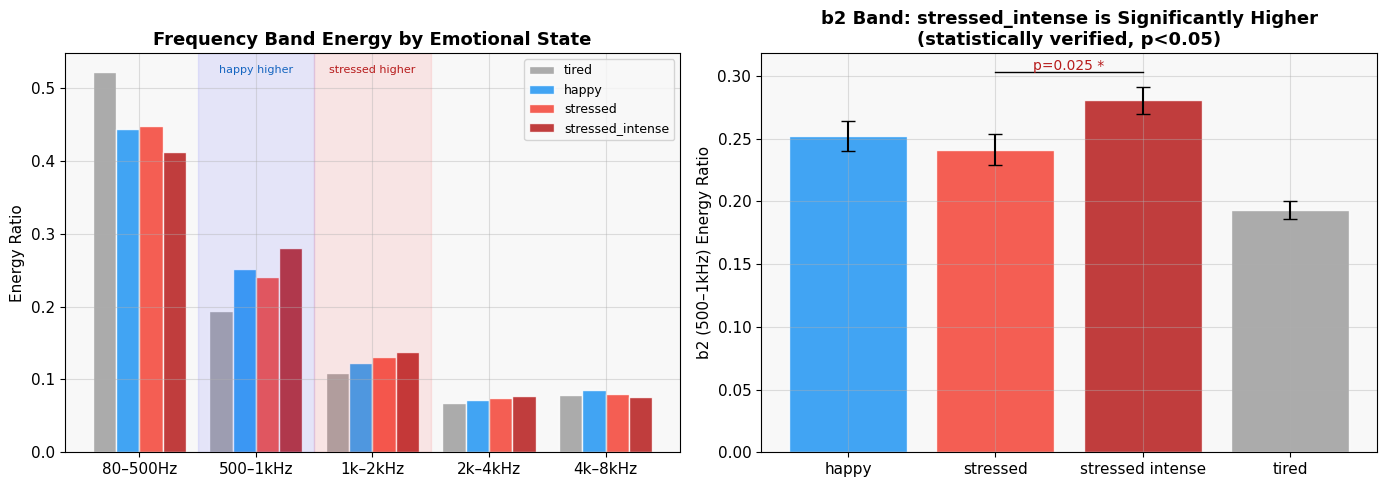

b2 (500-1kHz) means:
  happy:            0.2522
  stressed:         0.2413
  stressed_intense: 0.2807  ← significantly higher (p=0.025)
  tired:            0.1934


In [33]:
bands      = ['b1_80_500', 'b2_500_1k', 'b3_1k_2k', 'b4_2k_4k', 'b5_4k_8k']
band_names = ['80–500Hz', '500–1kHz', '1k–2kHz', '2k–4kHz', '4k–8kHz']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 밴드별 에너지 비율
x = np.arange(len(bands))
w = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, label in enumerate(label_order):
    vals = [main[main['label']==label][b].mean() for b in bands]
    ax1.bar(x + offsets[i]*w, vals, w,
            label=label, color=COLORS[label], alpha=0.85, edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(band_names)
ax1.set_ylabel('Energy Ratio')
ax1.set_title('Frequency Band Energy by Emotional State')
ax1.legend(fontsize=9)

# 핵심 구간 강조
ax1.axvspan(0.5, 1.5, alpha=0.08, color='blue', label='_nolegend_')
ax1.axvspan(1.5, 2.5, alpha=0.08, color='red',  label='_nolegend_')
ax1.text(1.0, ax1.get_ylim()[1]*0.95, 'happy higher', ha='center', fontsize=8, color='#1565C0')
ax1.text(2.0, ax1.get_ylim()[1]*0.95, 'stressed higher', ha='center', fontsize=8, color='#B71C1C')

# 오른쪽: stressed vs stressed_intense — b2 통계 검증
s  = main[main['label']=='stressed']['b2_500_1k']
si = main[main['label']=='stressed_intense']['b2_500_1k']
h  = main[main['label']=='happy']['b2_500_1k']
t  = main[main['label']=='tired']['b2_500_1k']

means = [h.mean(), s.mean(), si.mean(), t.mean()]
sems  = [h.sem(),  s.sem(),  si.sem(),  t.sem()]
cols  = [COLORS[l] for l in ['happy','stressed','stressed_intense','tired']]
xlabels = ['happy', 'stressed', 'stressed intense', 'tired']

bars = ax2.bar(xlabels, means, yerr=sems, capsize=5,
               color=cols, alpha=0.85, edgecolor='white')

# 유의성 표시
_, p = stats.ttest_ind(si, s)
y_max = max(means) + max(sems) + 0.01
ax2.plot([1, 2], [y_max, y_max], 'k-', linewidth=1)
ax2.text(1.5, y_max + 0.002, f'p={p:.3f} *', ha='center', fontsize=10, color='#B71C1C')

ax2.set_ylabel('b2 (500–1kHz) Energy Ratio')
ax2.set_title('b2 Band: stressed_intense is Significantly Higher\n(statistically verified, p<0.05)')

plt.tight_layout()
plt.savefig('plots/03_band_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"b2 (500-1kHz) means:")
print(f"  happy:            {h.mean():.4f}")
print(f"  stressed:         {s.mean():.4f}")
print(f"  stressed_intense: {si.mean():.4f}  ← significantly higher (p={p:.3f})")
print(f"  tired:            {t.mean():.4f}")


## 4. Tired Is Cleanly Separable by Energy

The `tired` class shows a distinctly lower energy profile — this aligns with the intuition  
that fatigue reduces vocal effort and resonance.


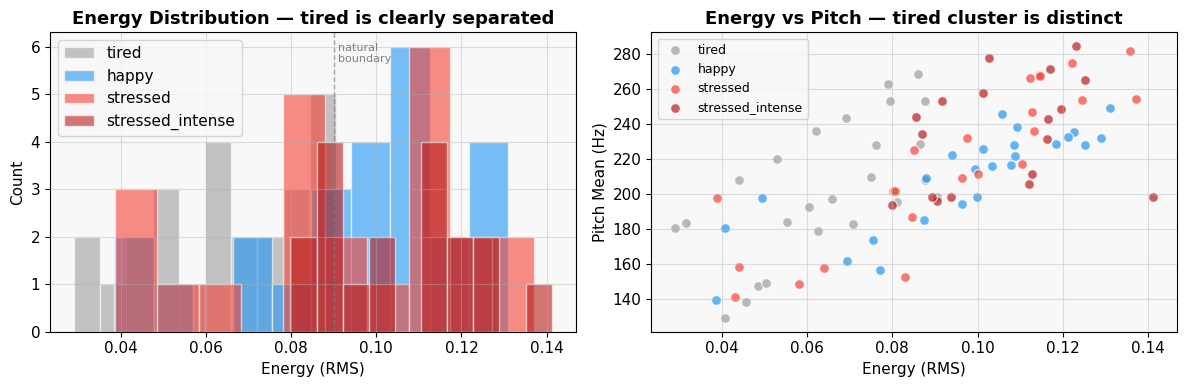

tired energy mean:  0.0647
others energy mean: 0.0980
t-test p-value: 0.000000  ← highly significant


In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# energy 분포
for label in label_order:
    vals = main[main['label']==label]['energy_rms']
    ax1.hist(vals, bins=10, alpha=0.6, label=label,
             color=COLORS[label], edgecolor='white')
ax1.set_xlabel('Energy (RMS)')
ax1.set_ylabel('Count')
ax1.set_title('Energy Distribution — tired is clearly separated')
ax1.legend()
ax1.axvline(0.09, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax1.text(0.091, ax1.get_ylim()[1]*0.9, 'natural\nboundary', fontsize=8, color='gray')

# energy vs pitch scatter
for label in label_order:
    sub = main[main['label']==label]
    ax2.scatter(sub['energy_rms'], sub['pitch_mean'],
                label=label, color=COLORS[label], alpha=0.7, s=50, edgecolors='white')
ax2.set_xlabel('Energy (RMS)')
ax2.set_ylabel('Pitch Mean (Hz)')
ax2.set_title('Energy vs Pitch — tired cluster is distinct')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/04_tired_separation.png', dpi=150, bbox_inches='tight')
plt.show()

# t-test: tired vs rest
tired_e  = main[main['label']=='tired']['energy_rms']
others_e = main[main['label']!='tired']['energy_rms']
_, p = stats.ttest_ind(tired_e, others_e)
print(f"tired energy mean:  {tired_e.mean():.4f}")
print(f"others energy mean: {others_e.mean():.4f}")
print(f"t-test p-value: {p:.6f}  ← highly significant")


## 5. Classification Performance

Random Forest classifier trained on standardized features.  
Evaluated with **Stratified 5-Fold Cross-Validation** (proper train/test separation).


CV F1-macro: 0.666 ± 0.091
Per-fold:    [0.57  0.703 0.759 0.753 0.546]

              precision    recall  f1-score   support

       happy       0.56      0.36      0.44        25
    stressed       0.65      0.76      0.70        41
       tired       0.81      0.88      0.85        25

    accuracy                           0.68        91
   macro avg       0.67      0.67      0.66        91
weighted avg       0.67      0.68      0.67        91



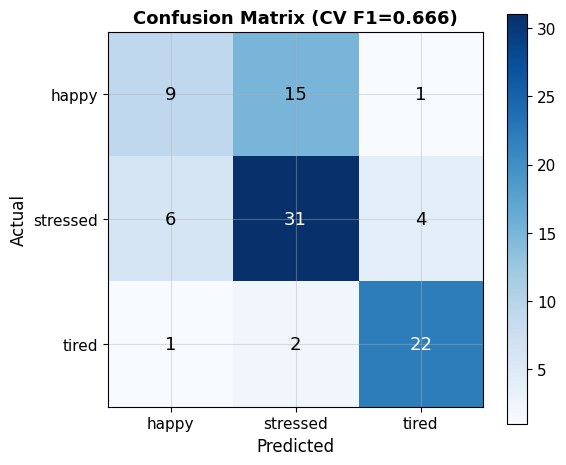

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import itertools

feat_cols = ['pitch_mean','pitch_std','energy_rms','speech_rate',
             'spectral_centroid','spectral_rolloff','spectral_bandwidth','zcr',
             'b1_80_500','b2_500_1k','b3_1k_2k','b4_2k_4k','b5_4k_8k',
             'mfcc_1','mfcc_2','mfcc_3','mfcc_4','mfcc_5','mfcc_6',
             'mfcc_7','mfcc_8','mfcc_9','mfcc_10','mfcc_11','mfcc_12','mfcc_13']

# 3클래스 (stressed 통합)
data3 = main3[main3['label'].isin(['happy','tired','stressed'])].copy()
le = LabelEncoder()
X  = data3[feat_cols]
y  = le.fit_transform(data3['label'])

rf  = RandomForestClassifier(n_estimators=300, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores   = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro')
y_pred   = cross_val_predict(rf, X, y, cv=cv)

print(f"CV F1-macro: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Per-fold:    {scores.round(3)}")
print()
print(classification_report(y, y_pred, target_names=le.classes_))

# confusion matrix
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, fontsize=11)
ax.set_yticklabels(le.classes_, fontsize=11)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix (CV F1={scores.mean():.3f})', fontsize=13)
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i,j], ha='center', va='center',
            color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('plots/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Feature Importance

Which features drive the classification — and do they align with our acoustic intuition?


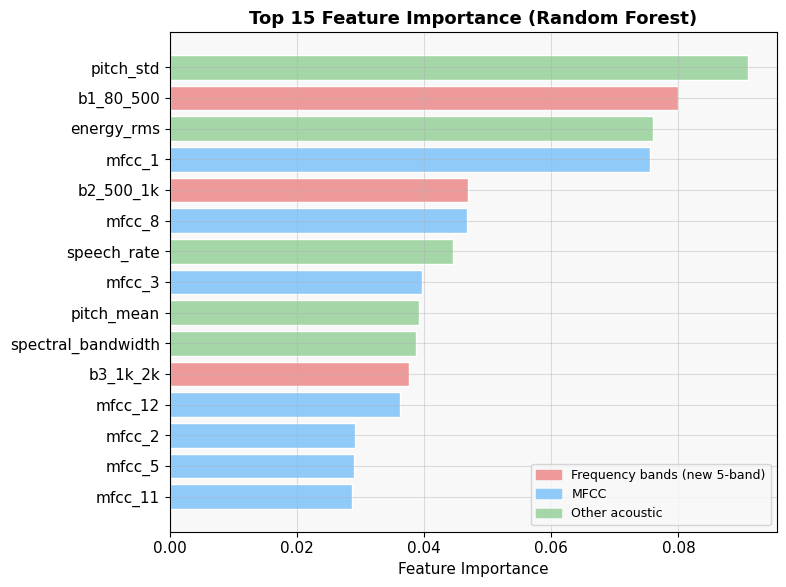

Top 5 features:
   feature  importance
 pitch_std    0.090943
 b1_80_500    0.079928
energy_rms    0.076023
    mfcc_1    0.075511
 b2_500_1k    0.046896


In [36]:
rf.fit(X, y)
imp = pd.DataFrame({'feature': feat_cols, 'importance': rf.feature_importances_})
imp = imp.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = []
for f in imp['feature']:
    if f in ['b2_500_1k','b3_1k_2k','b4_2k_4k','b5_4k_8k','b1_80_500']:
        colors.append('#EF9A9A')   # 밴드 피처 강조
    elif f.startswith('mfcc'):
        colors.append('#90CAF9')
    else:
        colors.append('#A5D6A7')

ax.barh(imp['feature'], imp['importance'], color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Feature Importance (Random Forest)')

patches = [
    mpatches.Patch(color='#EF9A9A', label='Frequency bands (new 5-band)'),
    mpatches.Patch(color='#90CAF9', label='MFCC'),
    mpatches.Patch(color='#A5D6A7', label='Other acoustic'),
]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('plots/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(imp.tail(5)[['feature','importance']].iloc[::-1].to_string(index=False))


## 7. Summary of Findings

| Finding | Method | Result |
|---|---|---|
| Sample rate mismatch corrupted features | Extraction comparison | 230Hz centroid gap — fixed by standardization |
| tired separable by energy alone | t-test | p < 0.0001 |
| stressed_intense has higher b2 (500-1kHz) | t-test | p = 0.025 ★ |
| b3 (1-2kHz) higher in stressed vs happy | t-test | p = 0.046 ★ |
| 5-band split improves on 3-band | Feature importance | b2 enters Top 5 features |
| CV F1-macro (3-class, proper split) | StratifiedKFold | 0.666 ± 0.091 |

### Key Insight
> The perceptual observation that stressed speech feels "heavier" in the 1–2kHz range  
> while happy speech resonates more in 500–1kHz was **statistically verified** from personal voice data.  
> This forms the acoustic basis of the baseline-relative inference pipeline.

### Next Steps
- Add MFCC delta features (temporal dynamics)
- Integrate personal baseline calibration as delta features
- Build confidence-aware suggestion layer


## 8. Ablation Study — Which Features Actually Matter?

Each custom feature is removed one at a time to verify its individual contribution.

This isolates the effect of **VTS**, **VOI**, **b_6k_8k**, and **MFCC-derived** features
— all designed from perceptual acoustic observations.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('features_standardized.csv')
hb = pd.read_csv('highband_features.csv')

main = df[df['label'].isin(['happy','tired','stressed','stressed_intense'])].copy()
main['label'] = main['label'].replace({'stressed_intense': 'stressed'})
main = main.merge(hb[['file','environment','b_6k_8k']], on=['file','environment'], how='left')

def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

main['vts'] = (
    0.35 * normalize(main['pitch_std']) +
    0.25 * normalize(main['b3_1k_2k']) +
    0.25 * normalize(main['energy_rms']) -
    0.15 * normalize(main['b2_500_1k'])
)
main['voi'] = (
    0.40 * normalize(main['b2_500_1k']) +
    0.35 * normalize(main['b_6k_8k']) -
    0.25 * normalize(main['b3_1k_2k'])
)
mfcc_cols = [f'mfcc_{i}' for i in range(1, 14)]
main['mfcc_energy'] = np.sqrt((main[mfcc_cols] ** 2).sum(axis=1))
main['mfcc_var']    = main[mfcc_cols].var(axis=1)
x = np.arange(13)
main['mfcc_slope']  = main[mfcc_cols].apply(
    lambda row: np.polyfit(x, row.values, 1)[0], axis=1)

base_cols = [
    'pitch_mean','pitch_std','energy_rms','speech_rate',
    'spectral_centroid','spectral_rolloff','spectral_bandwidth','zcr',
    'b1_80_500','b2_500_1k','b3_1k_2k','b4_2k_4k','b5_4k_8k'
] + mfcc_cols

full_cols = base_cols + ['vts','voi','b_6k_8k','mfcc_energy','mfcc_var','mfcc_slope']

le = LabelEncoder()
y  = le.fit_transform(main['label'])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, max_features='sqrt',
    min_samples_leaf=1, min_samples_split=2, random_state=42
)

# Full model (baseline)
s_full = cross_val_score(rf, main[full_cols], y, cv=cv, scoring='f1_macro').mean()

# 각 피처 제거했을 때 성능
ablations = [
    ('Full model (all features)',    full_cols,                                          'full'),
    ('w/o VTS',                      [c for c in full_cols if c != 'vts'],               'remove'),
    ('w/o VOI',                      [c for c in full_cols if c != 'voi'],               'remove'),
    ('w/o b_6k_8k (6-8kHz)',         [c for c in full_cols if c != 'b_6k_8k'],          'remove'),
    ('w/o MFCC-derived',             [c for c in full_cols if c not in
                                      ['mfcc_energy','mfcc_var','mfcc_slope']],          'remove'),
    ('w/o VTS + VOI + b_6k_8k',     [c for c in full_cols if c not in
                                      ['vts','voi','b_6k_8k']],                          'remove'),
    ('Base features only',           base_cols,                                          'base'),
]

print('=== Ablation Study: Feature Contribution ===')
print(f'{"Model":45} {"F1":>6}  {"vs Full":>8}')
print('-' * 62)

results = []
for name, cols, typ in ablations:
    s = cross_val_score(rf, main[cols], y, cv=cv, scoring='f1_macro').mean()
    diff = s - s_full
    diff_str = f'{diff:+.3f}' if typ != 'full' else '—'
    print(f'{name:45} {s:.3f}  {diff_str:>8}')
    results.append((name, s, typ))

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))

names  = [r[0] for r in results]
scores = [r[1] for r in results]
types  = [r[2] for r in results]

colors = []
for t in types:
    if t == 'full':   colors.append('#1565C0')
    elif t == 'base': colors.append('#EF9A9A')
    else:             colors.append('#90CAF9')

bars = ax.barh(range(len(results)), scores, color=colors, edgecolor='white')

for i, (bar, score, (name, s, typ)) in enumerate(zip(bars, scores, results)):
    diff = s - s_full
    diff_str = f'  {diff:+.3f}' if typ != 'full' else ''
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'F1={score:.3f}{diff_str}', va='center', fontsize=9)

ax.set_yticks(range(len(results)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('F1-macro Score')
ax.set_xlim(0.55, 0.90)
ax.axvline(s_full, color='#1565C0', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Ablation Study — Impact of Each Custom Feature', fontsize=13, fontweight='bold')

patches = [
    mpatches.Patch(color='#1565C0', label='Full model'),
    mpatches.Patch(color='#90CAF9', label='Feature removed'),
    mpatches.Patch(color='#EF9A9A', label='Base features only'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('plots/08_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> plots/08_ablation_study.png')
